# The tripolar north fold: do `diff` and `interp` work across the seam?

Tripolar ocean grids (MOM6, NEMO, Oceananigans) fold the northern edge of the
domain onto itself. If xgcm handles the fold correctly, fields built with
`interp` and `diff` should be **smooth across the seam**, differing from the
naive (no-fold) calculation **only along the fold row**.

We test this for **three models** (real surface velocities `u`,`v`) with two
diagnostics, each crossing the fold through a different operation:

* **surface current speed** $\sqrt{u^2+v^2}$ from `interp` — shown both
  interpolated to **tracer (centre) points** (the `v`→centre step crosses the
  fold) and to **cell corners / vorticity points** (the `u`→corner step crosses
  it), so *both* velocity components are exercised across the seam;
* the **Rossby number** $\mathrm{Ro}=\zeta/f$ from `diff`, where
  $\zeta=\partial v/\partial x-\partial u/\partial y$ (derivatives divided by the
  cell spacings) and $f=2\Omega\sin\phi$.

Each diagnostic is a **3×3 grid**: columns are the models, rows are **naive**
(no fold), **fold-aware**, and their **difference**. The Arctic is drawn as a
single continuous polar mesh (cell corners reconstructed *through* the fold), so
the seam itself is plotted rather than left as a blank line — the **difference**
row then lights up exactly the cells the fold changes: a thin line across the
pole. We also continue the field across the seam directly (a 1-D transect) as
the cleanest correctness check. MOM6/NEMO use a `"corner"` fold pivot,
Oceananigans a `"u"` pivot.

> **Dependencies** — the MOM6/NEMO sections read CMIP6 from the Pangeo cloud
> (`pip install zarr gcsfs`); plots use `cartopy`.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm

from xgcm import Grid
from xgcm.padding import pad

so = {"storage_options": {"token": "anon"}}
EARTH_RADIUS = 6371e3
OMEGA = 7.2921e-5


def _ll2xyz(lon, lat):
    lo, la = np.radians(lon), np.radians(lat)
    return np.stack([np.cos(la) * np.cos(lo), np.cos(la) * np.sin(lo), np.sin(la)], -1)


def _xyz2ll(v):
    x, y, z = v[..., 0], v[..., 1], v[..., 2]
    r = np.sqrt(x * x + y * y + z * z)
    r = np.where(r == 0, 1.0, r)
    return np.degrees(np.arctan2(y, x)), np.degrees(np.arcsin(np.clip(z / r, -1, 1)))


def _fold_pad_top(arr2d, pivot):
    '''Append one row at the top (j=ny) of a centre-point scalar field using
    xgcm's fold reconstruction -- this is the seam partner row.'''
    ny, nx = arr2d.shape
    ds = xr.Dataset(coords=dict(x_c=np.arange(nx), x_f=np.arange(nx),
                                y_c=np.arange(ny), y_f=np.arange(ny)))
    g = Grid(ds, coords={"X": {"center": "x_c", "right": "x_f"},
                         "Y": {"center": "y_c", "right": "y_f"}},
             boundary={"X": "periodic", "Y": {"fold": pivot}}, autoparse_metadata=False)
    da = xr.DataArray(arr2d, dims=["y_c", "x_c"])
    return np.asarray(pad(da, g, boundary_width={"Y": (0, 1)}).values)


def cell_corners(lon, lat, pivot):
    '''Centre lon/lat (ny,nx) -> cell-corner lattice (ny+1,nx+1) for pcolormesh
    (shading="flat"). The top edge is closed across the fold seam via xgcm's
    fold reconstruction, and averaging is done in 3-D so the pole/dateline are
    handled cleanly -- so the Arctic is drawn as one continuous mesh with no
    masked seam.'''
    lon_p, lat_p = _fold_pad_top(lon, pivot), _fold_pad_top(lat, pivot)  # (ny+1,nx)
    xyz = _ll2xyz(lon_p, lat_p)
    xyz = np.concatenate([2 * xyz[:1] - xyz[1:2], xyz], axis=0)          # extrap bottom
    xyz = np.concatenate([xyz[:, -1:], xyz, xyz[:, :1]], axis=1)        # periodic X
    blk = (xyz[:-1, :-1] + xyz[1:, :-1] + xyz[:-1, 1:] + xyz[1:, 1:]) / 4.0
    return _xyz2ll(blk)

## Helpers

`package` puts a model's `u`,`v` on a common staggered index grid and masks land
(cells whose velocity is missing, or zero where zeros dominate — e.g. the
Oceananigans immersed boundary), so land never leaks through `interp`/`diff`.

In [2]:
def package(uo, vo, lon, lat, fold, label):
    '''Bundle surface velocities on a common staggered index grid, masking land.'''
    a = lambda x: np.asarray(getattr(x, "values", x), dtype=float)
    uo, vo, lon, lat = a(uo), a(vo), a(lon), a(lat)
    # land = missing, or (where zeros dominate, e.g. immersed boundaries) zero
    def mask_land(z):
        zz = np.where(np.isfinite(z), z, np.nan)
        if np.mean(z == 0) > 0.05:
            zz = np.where(z == 0, np.nan, zz)
        return zz
    uo, vo = mask_land(uo), mask_land(vo)
    ny, nx = uo.shape
    coords = dict(x_c=np.arange(nx), x_f=np.arange(nx), y_c=np.arange(ny), y_f=np.arange(ny))
    u = xr.DataArray(uo, dims=["y_c", "x_f"]).assign_coords(x_f=coords["x_f"], y_c=coords["y_c"])
    v = xr.DataArray(vo, dims=["y_f", "x_c"]).assign_coords(x_c=coords["x_c"], y_f=coords["y_f"])
    # seam-closing cell-corner lattice (ny+1, nx+1) for pcolormesh(shading="flat")
    lonc, latc = cell_corners(lon, lat, fold)
    return dict(coords=coords, u=u, v=v, lon=lon, lat=lat, lonc=lonc, latc=latc,
                fold=fold, label=label)


def _haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))
    h = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * EARTH_RADIUS * np.arcsin(np.sqrt(h))


def cell_spacings(lon, lat):
    lonE = np.concatenate([lon, lon[:, :1]], axis=1)
    latE = np.concatenate([lat, lat[:, :1]], axis=1)
    dx = _haversine(lonE[:, :-1], latE[:, :-1], lonE[:, 1:], latE[:, 1:])
    dy = np.empty_like(lat)
    dy[:-1] = _haversine(lon[:-1], lat[:-1], lon[1:], lat[1:])
    dy[-1] = dy[-2]
    return xr.DataArray(dx, dims=["y_f", "x_f"]), xr.DataArray(dy, dims=["y_f", "x_f"])


def _grid(coords, edge, ybc):
    return Grid(xr.Dataset(coords=coords),
                coords={"X": {"center": "x_c", edge: "x_f"},
                        "Y": {"center": "y_c", edge: "y_f"}},
                boundary={"X": "periodic", "Y": ybc}, autoparse_metadata=False)


def speed_centre(m, fold):
    '''sqrt(u^2+v^2) at tracer points; the v->centre interp crosses the fold.'''
    g = _grid(m["coords"], "left", {"fold": m["fold"]} if fold else "extend")
    uc = g.interp(m["u"], "X")
    vc = (g.interp({"Y": m["v"]}, "Y", other_component={"X": m["u"]}, boundary="extend")
          if fold else g.interp(m["v"], "Y", boundary="extend"))
    return np.hypot(uc, vc)


def speed_corner(m, fold):
    '''sqrt(u^2+v^2) at cell corners; the u->corner interp crosses the fold.'''
    g = _grid(m["coords"], "right", {"fold": m["fold"]} if fold else "extend")
    vc = g.interp(m["v"], "X")
    uc = (g.interp({"X": m["u"]}, "Y", other_component={"Y": m["v"]}, boundary="extend")
          if fold else g.interp(m["u"], "Y", boundary="extend"))
    return np.hypot(uc, vc)


def rossby(m, fold):
    '''Ro = (dv/dx - du/dy)/f at the cell corner; the du/dy diff crosses the fold.'''
    g = _grid(m["coords"], "right", {"fold": m["fold"]} if fold else "extend")
    dx, dy = cell_spacings(m["lon"], m["lat"])
    dvdx = g.diff(m["v"], "X", boundary="fill") / dx
    dudy = (g.diff({"X": m["u"]}, "Y", other_component={"Y": m["v"]}, boundary="fill")
            if fold else g.diff(m["u"], "Y", boundary="extend")) / dy
    f = xr.DataArray(2 * OMEGA * np.sin(np.radians(m["lat"])), dims=["y_f", "x_f"])
    return (dvdx - dudy) / f


def seam_transect(models, K=6, ncols=4):
    '''Continue the (scalar) surface speed across the fold into the halo. The
    fold fills the halo with the true seam-partner row -- a smooth physical
    continuation of the field across the pole -- whereas the naive boundary
    just extends the edge value (a flat line). One panel per model; a few ocean
    columns each. Fold lines keep varying past the seam; naive lines go flat.'''
    fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4.2))
    axes = np.atleast_1d(axes)
    for k, (ax, m) in enumerate(zip(axes, models)):
        g = _grid(m["coords"], "left", {"fold": m["fold"]})
        uc = g.interp(m["u"], "X")
        vc = g.interp({"Y": m["v"]}, "Y", other_component={"X": m["u"]}, boundary="extend")
        S = xr.DataArray(np.asarray(np.hypot(uc, vc).values), dims=["y_c", "x_c"])
        ny = S.sizes["y_c"]
        Sf = np.asarray(pad(S, _grid(m["coords"], "right", {"fold": m["fold"]}),
                            boundary_width={"Y": (0, K)}).values)
        Se = np.asarray(pad(S, _grid(m["coords"], "right", "extend"),
                            boundary_width={"Y": (0, K)}).values)
        x = np.arange(ny - K, ny + K)
        win = Sf[ny - K:ny + K]
        # need a clean run up to the seam; tolerate NaNs deeper in the halo (gaps ok)
        approach = np.isfinite(Sf[ny - K:ny]).all(axis=0)
        nfin = np.isfinite(win).sum(axis=0)
        good = np.where(approach & (nfin >= K + 2))[0]
        if good.size == 0:                       # coarse, land-locked cap: take most-finite cols
            good = np.argsort(nfin)[::-1][:ncols]
        sel = good[np.linspace(0, len(good) - 1, min(ncols, len(good))).astype(int)]
        for j, i in enumerate(sel):
            lab = (j == 0 and k == 0)
            ax.plot(x, Se[ny - K:ny + K, i], "o--", color="C1", ms=3, alpha=.8,
                    label="naive (extend)" if lab else None)
            ax.plot(x, Sf[ny - K:ny + K, i], "o-", color="C0", ms=3, alpha=.9,
                    label="fold (reconstructed)" if lab else None)
        ax.axvline(ny - 0.5, color="k", ls=":", alpha=.6,
                   label="fold seam" if k == 0 else None)
        ax.set_title(m["label"], fontsize=10)
        ax.set_xlabel("Y index  (interior → halo)")
        if k == 0:
            ax.set_ylabel("surface speed [m s$^{-1}$]")
    axes[0].legend(fontsize=8, loc="best")
    fig.suptitle("Across the seam, the fold reconstructs the real field; the naive boundary flatlines",
                 fontsize=12)
    plt.tight_layout()
    plt.show()


def grid3x3(fn, models, *, title, cmap, label, norm=None, diff_cmap="RdBu_r", vlim=None):
    '''Plot fn(m, fold) for fold in {naive, fold} and their difference, as a
    3x3 grid (columns = models; rows = naive / fold / naive-minus-fold).'''
    naive = [fn(m, False) for m in models]
    fold = [fn(m, True) for m in models]
    diff = [a - b for a, b in zip(naive, fold)]

    def sym(fields, pct=99, nonzero=False):
        # symmetric limit per field, then take the median across models so one
        # eddy-rich model doesn't wash the others out
        lims = []
        for f in fields:
            v = np.abs(np.asarray(f.values).ravel())
            v = v[np.isfinite(v)]
            if nonzero:
                v = v[v > 0]
            lims.append(float(np.nanpercentile(v, pct)) if v.size else 1.0)
        return float(np.median(lims))

    if norm is not None:
        main = None
    elif vlim is not None:
        main = vlim
    else:
        main = sym(fold, pct=96)
    rows = [("naive (no fold)", naive), ("fold", fold), ("naive − fold", diff)]
    proj = ccrs.NorthPolarStereo()
    fig, axes = plt.subplots(3, 3, figsize=(15, 14), subplot_kw=dict(projection=proj))
    cmap_m = plt.get_cmap(cmap).copy(); cmap_m.set_bad("lightgray")     # land -> grey
    cmap_d = plt.get_cmap(diff_cmap).copy(); cmap_d.set_bad("lightgray")
    # Project the seam-closed corner lattice into the stereographic plane ourselves
    # and draw there: this avoids cartopy's PlateCarree antimeridian wrap, which
    # would otherwise slice white gaps across the cap. Corners that fall outside
    # the projection (far south) become non-finite; mask any cell touching one
    # and replace those coords with a dummy (such cells are never drawn).
    pdata = []
    for m in models:
        xyz = proj.transform_points(ccrs.PlateCarree(), m["lonc"], m["latc"])
        Xp, Yp = xyz[..., 0].copy(), xyz[..., 1].copy()
        cf = np.isfinite(Xp) & np.isfinite(Yp)
        cell_ok = cf[:-1, :-1] & cf[1:, :-1] & cf[:-1, 1:] & cf[1:, 1:]
        Xp[~cf] = 0.0; Yp[~cf] = 0.0
        pdata.append((Xp, Yp, cell_ok))
    for r, (rlabel, row) in enumerate(rows):
        is_diff = (r == 2)
        for c, m in enumerate(models):
            ax = axes[r, c]
            ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
            ax.set_facecolor("lightgray")
            kw = dict(shading="flat")
            arr = np.asarray(row[c].values)
            Xp, Yp, cell_ok = pdata[c]
            if is_diff:
                # the fold changes the field only at the seam, and by amounts that
                # differ by orders of magnitude between models -- normalise each
                # panel by its own Arctic-cap maximum so the seam line is visible
                # everywhere (the colour shows *where* the fold acts, not magnitude)
                cap = np.asarray(m["lat"]) > 55
                vmax = np.nanmax(np.abs(np.where(cap, arr, np.nan)))
                arr = arr / (vmax if np.isfinite(vmax) and vmax > 0 else 1.0)
                kw.update(cmap=cmap_d, vmin=-1, vmax=1)
            elif norm is not None:
                kw.update(cmap=cmap_m, norm=norm)
            else:
                kw.update(cmap=cmap_m, vmin=-main, vmax=main)
            bad = ~np.isfinite(arr) | ~cell_ok   # land (NaN) -> grey; seam is now drawn
            pm = ax.pcolormesh(Xp, Yp, np.ma.masked_where(bad, arr), **kw)
            ax.coastlines(linewidth=0.3, color="0.5")
            ax.gridlines(color="k", alpha=0.15, linewidth=0.2)
            if r == 0:
                ax.set_title(m["label"], fontsize=10)
            if c == 0:
                ax.text(-0.12, 0.5, rlabel, transform=ax.transAxes, rotation=90,
                        va="center", ha="center", fontsize=11, fontweight="bold")
        clabel = label if not is_diff else "naive − fold  (per-panel max → ±1)"
        fig.colorbar(pm, ax=list(axes[r, :]), shrink=0.7, pad=0.02, label=clabel)
    fig.suptitle(title, fontsize=14, y=0.93)
    plt.show()

## Load the three models

CMIP6 surface velocities for MOM6 (GFDL-CM4) and NEMO (IPSL-CM6A-LR) from the
Pangeo cloud, plus a realistic 1° ClimaOcean/Oceananigans surface snapshot.
CMIP6 masks its redundant northern row, so we drop it before folding.

In [3]:
def _cmip6_surface(source_id, version, fold, label):
    inst = {"GFDL-CM4": "NOAA-GFDL", "IPSL-CM6A-LR": "IPSL"}[source_id]
    base = (f"gs://cmip6/CMIP6/CMIP/{inst}/{source_id}/historical/"
            f"r1i1p1f1/Omon/{{var}}/gn/{version}/")

    def s(var):
        d = xr.open_dataset(base.format(var=var), engine="zarr", backend_kwargs=so)
        return d[var].isel(time=0).isel({d[var].dims[1]: 0})

    uo = s("uo").isel(y=slice(0, -1))
    vo = s("vo").isel(y=slice(0, -1))
    g = xr.open_dataset(base.format(var="uo"), engine="zarr", backend_kwargs=so)
    lonn = "lon" if "lon" in g.variables else "nav_lon"
    latn = "lat" if "lat" in g.variables else "nav_lat"
    return package(uo, vo, g[lonn].isel(y=slice(0, -1)).values,
                   g[latn].isel(y=slice(0, -1)).values, fold, label)


def _oceananigans():
    o = xr.open_dataset("oceananigans_tripolar.nc")
    return package(o["u"].transpose("y_c", "x_f"), o["v"].transpose("y_f", "x_c"),
                   o["lon_cc"].transpose("y_c", "x_c"), o["lat_cc"].transpose("y_c", "x_c"),
                   "u", "Oceananigans (ClimaOcean 1°)")


models = [
    _cmip6_surface("GFDL-CM4", "v20180701", "corner", "MOM6 (GFDL-CM4)"),
    _cmip6_surface("IPSL-CM6A-LR", "v20180803", "corner", "NEMO (IPSL-CM6A-LR)"),
    _oceananigans(),
]

## `interp` across the fold — surface speed at tracer (centre) points

The `v`→centre interpolation crosses the seam. Naive and fold-aware rows are
indistinguishable; the difference is confined to the fold row.

/opt/anaconda3/envs/xgcm-examples/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)
/opt/anaconda3/envs/xgcm-examples/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)


/opt/anaconda3/envs/xgcm-examples/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)


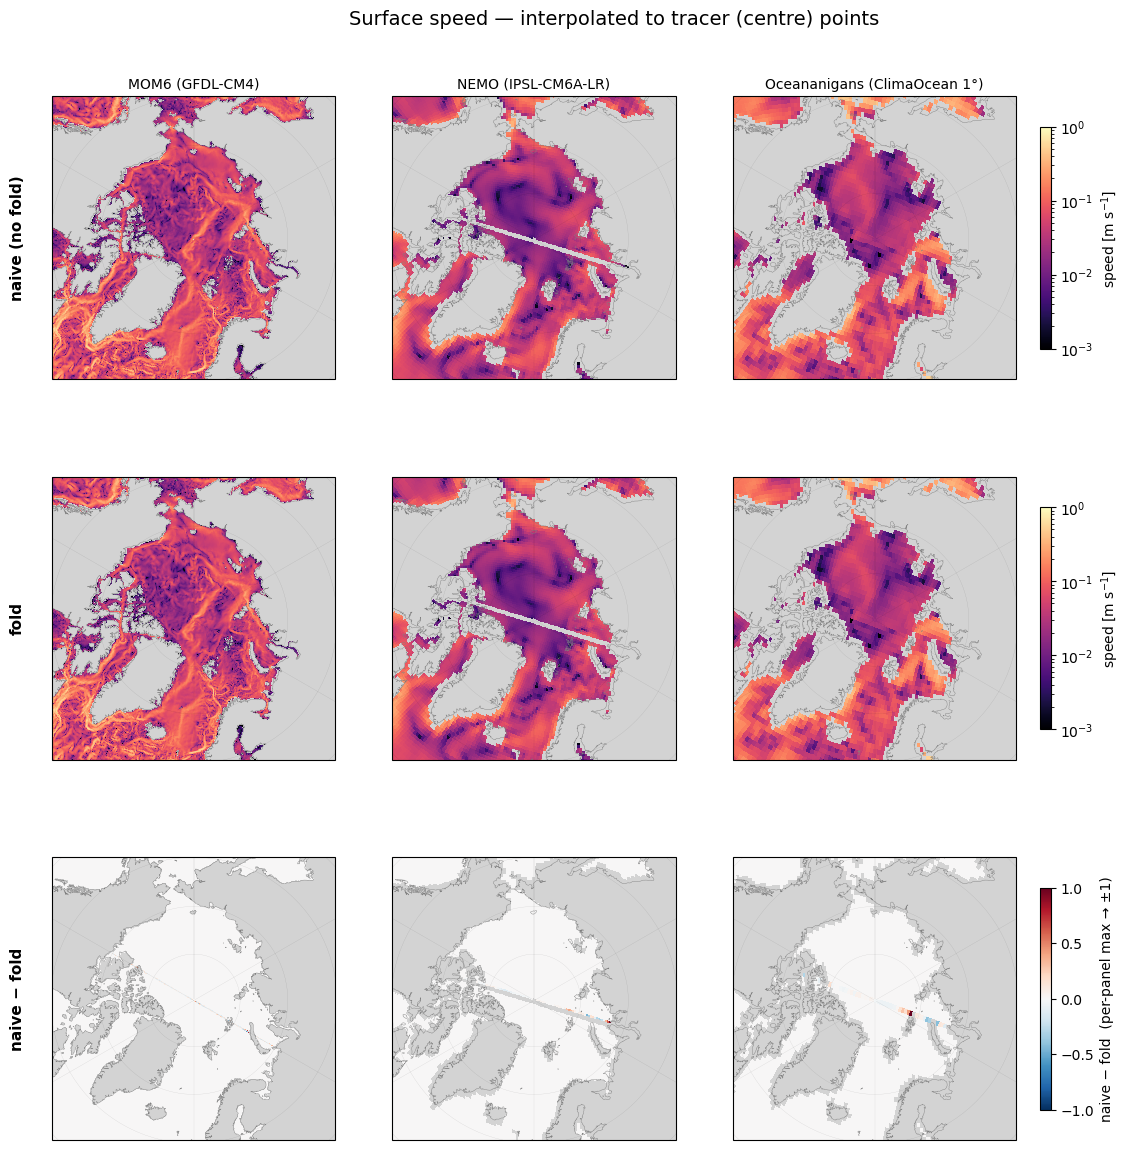

In [4]:
grid3x3(speed_centre, models, title="Surface speed — interpolated to tracer (centre) points",
        cmap="magma", norm=LogNorm(vmin=1e-3, vmax=1.0), label="speed [m s$^{-1}$]")

## `interp` across the fold — surface speed at corners (vorticity points)

Here the `u`→corner interpolation crosses the seam instead — the *other* velocity
component. Again smooth across the fold, differing only on the fold row.

/opt/anaconda3/envs/xgcm-examples/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)
/opt/anaconda3/envs/xgcm-examples/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)


/opt/anaconda3/envs/xgcm-examples/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)


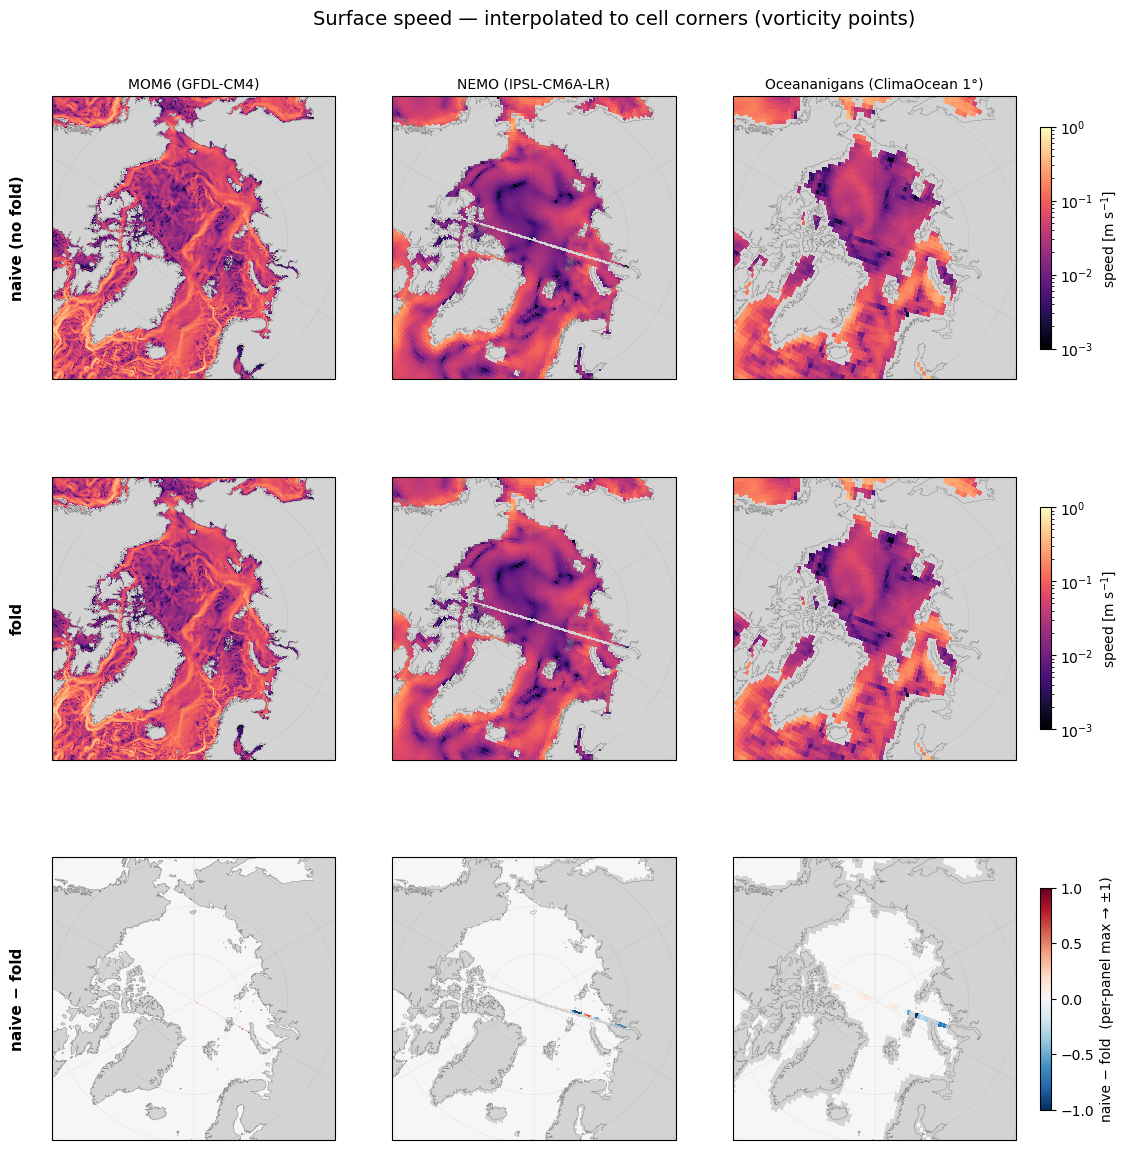

In [5]:
grid3x3(speed_corner, models, title="Surface speed — interpolated to cell corners (vorticity points)",
        cmap="magma", norm=LogNorm(vmin=1e-3, vmax=1.0), label="speed [m s$^{-1}$]")

## Why this works — continuing the field *across* the seam

The clearest single check: take the surface-speed field and ask what sits just
**beyond** the top row (the halo the operators reach into). The **fold** fills
that halo with the true seam-partner row, so the field continues **smoothly
across the pole** (the curve keeps its physical structure past the seam). The
**naive** boundary just repeats the edge value — a **flat line**. Each panel
follows a few ocean columns from the interior, across the seam (dotted), into
the halo, for all three pivots.

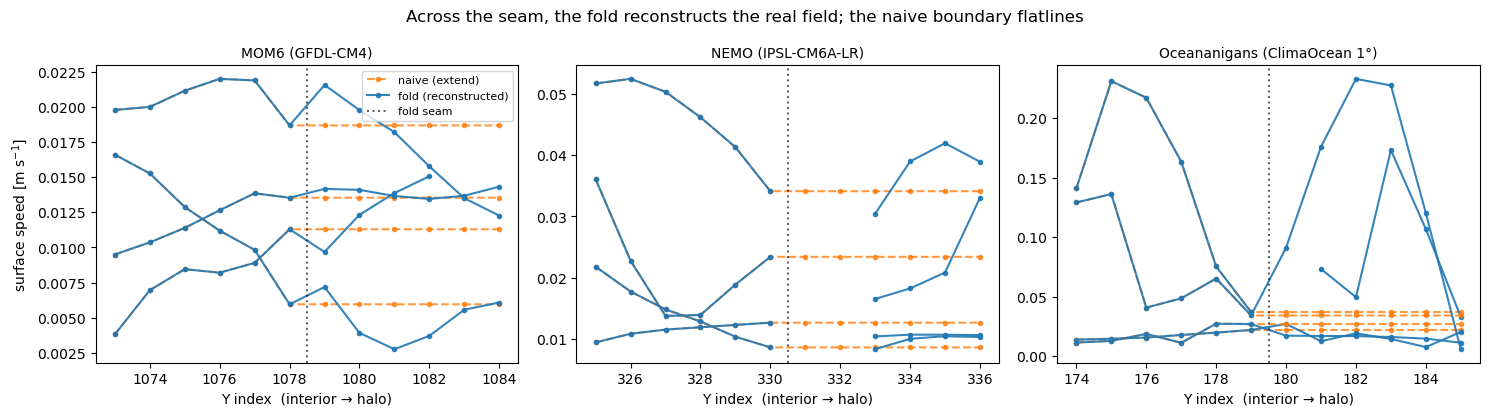

In [6]:
seam_transect(models)

## `diff` across the fold — Rossby number $\zeta/f$

The $\partial u/\partial y$ difference crosses the seam. The fold-aware Rossby
number is smooth across the pole; the naive one is not.

/opt/anaconda3/envs/xgcm-examples/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)
/opt/anaconda3/envs/xgcm-examples/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)


/opt/anaconda3/envs/xgcm-examples/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)


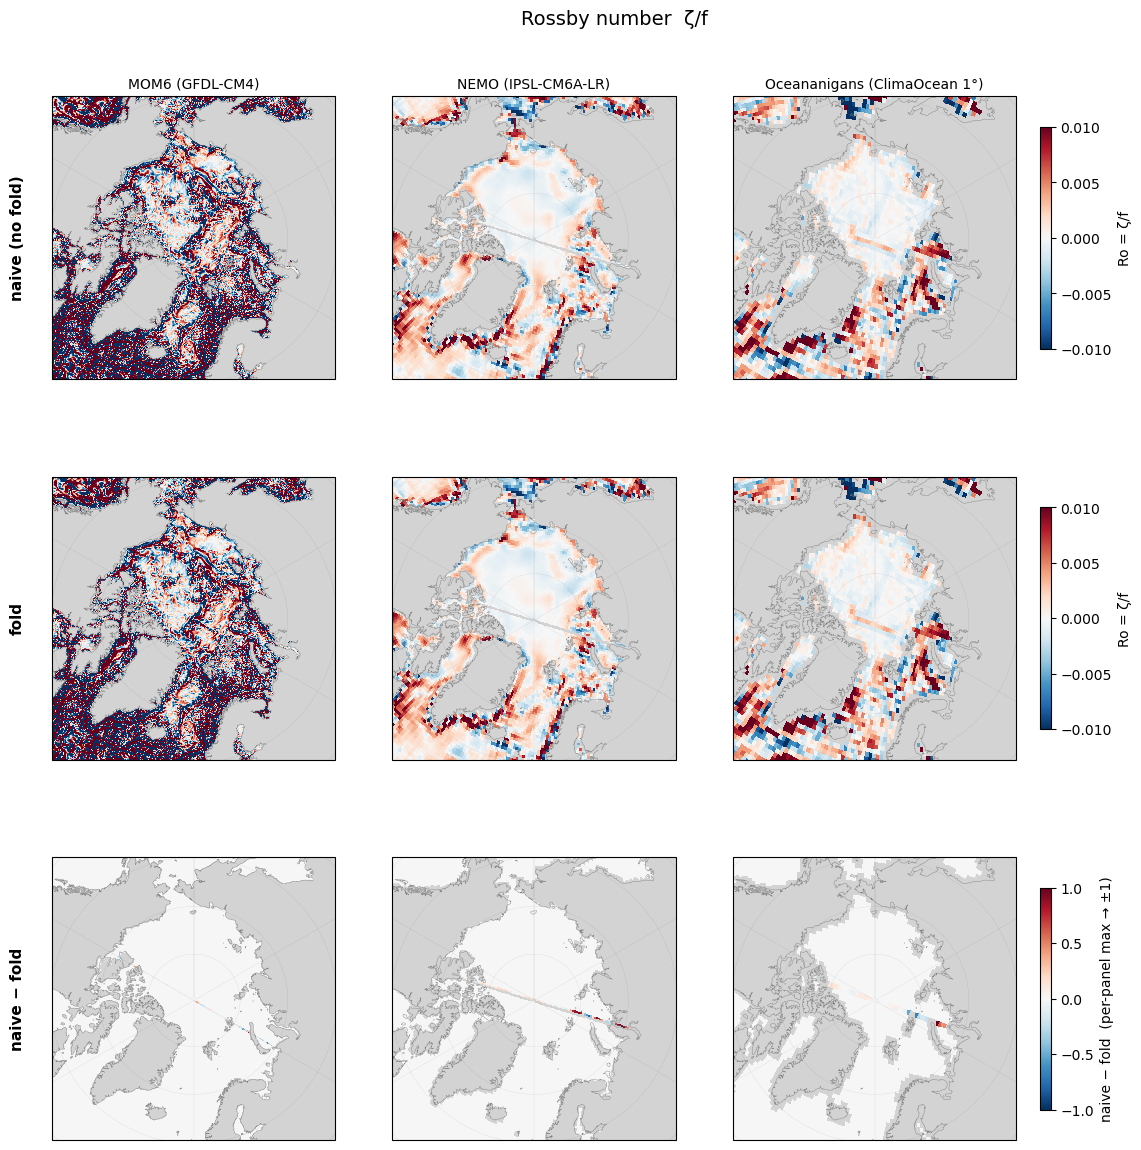

In [7]:
grid3x3(rossby, models, title="Rossby number  ζ/f", cmap="RdBu_r", label="Ro = ζ/f", vlim=0.01)

## Takeaway

For all three tripolar conventions (MOM6/NEMO `"corner"`, Oceananigans `"u"`),
**both** velocity components are interpolated and differenced correctly across
the North fold: surface speed (to centres *and* to corners) and the Rossby
number are smooth across the seam, and differ from the naive no-fold calculation
**only on the fold row** — which the difference panels (normalised per panel,
since the change differs by orders of magnitude between models) light up as a
single thin line of cells across the pole. The transect makes the same point
directly: the fold continues the field smoothly across the seam, while the naive
boundary flatlines. (In the NEMO panels that seam row runs across the central
Arctic and is mostly *land* — only ~70 of its cells are ocean — so it also shows
as a thin grey line; that is genuine missing data, not a plotting gap.) xgcm's `boundary={"Y": {"fold": ...}}` mirrors the seam and
sign-flips folded velocities so the standard staggered operators work across the
pole. (xgcm's reconstructed fold halos were verified to match Oceananigans' own
zipper exactly for the tracer and both velocity components.)

The faint band of vorticity right at the fold in the low-resolution Oceananigans
panel is *not* an artifact of the fold operators — it appears identically in the
naive and fold-aware columns because it lives in the model's **velocity field**:
a grid-scale "north-fold noise" (a step in the across-fold direction, smooth
along the seam) of the kind tripolar models develop near the seam, here
accentuated by the coarse 1° grid and short 10-day spin-up.

See the [grid topology](../grid_topology.md) docs and [`03_MOM6.ipynb`](03_MOM6.ipynb).